# Notebook 1: Introduction to JAX for Astrophysics

**Estimated time:** ~15 minutes

## Learning Objectives

By the end of this notebook, you will:
- Understand why JAX is valuable for astrophysics research
- Know the key differences between JAX and NumPy
- Be able to write basic JAX code
- Understand JAX's array immutability and device management

---

## 1.1 Motivation: Why JAX for Astrophysics?

Modern astrophysics faces significant computational challenges:

- **Large-scale simulations:** N-body dynamics, hydrodynamics, radiative transfer
- **Bayesian inference:** MCMC sampling over high-dimensional parameter spaces
- **Model fitting:** Optimizing complex forward models against observational data
- **Parameter exploration:** Evaluating models across thousands of parameter combinations

### What is JAX?

JAX is a Python library that provides:

1. **NumPy-like API:** Familiar interface for array operations
2. **Automatic differentiation:** Compute exact gradients of any function
3. **JIT compilation:** Compile Python code to optimized machine code via XLA
4. **Automatic vectorization:** Transform single-example code to batch operations
5. **Hardware acceleration:** Seamless execution on CPU, GPU, and TPU

### JAX's Design Philosophy

JAX is built around **composable function transformations** over **pure functions**:

```python
# Write a simple function
def f(x):
    return x ** 2

# Transform it in powerful ways
grad_f = jax.grad(f)              # Compute gradient
vmap_f = jax.vmap(f)              # Vectorize across batch
jit_f = jax.jit(f)                # Compile for speed
jit_vmap_grad_f = jax.jit(jax.vmap(jax.grad(f)))  # Compose all three!
```

This composability is JAX's superpower.

### When to Choose JAX?

| Library | Best For | Astrophysics Use Cases |
|---------|----------|------------------------|
| **NumPy** | Simple array operations, prototyping | Quick data analysis, small-scale calculations |
| **JAX** | Scientific computing with gradients, GPU acceleration | Model fitting, MCMC, differentiable simulations |
| **PyTorch** | Deep learning, neural networks | ML-based classification, image processing |
| **TensorFlow** | Production ML systems, large-scale deployment | Scalable ML pipelines |

**Choose JAX when you need:**
- Gradients of scientific computing code (not just neural networks)
- Composable transformations (jit, grad, vmap)
- NumPy-like interface with GPU acceleration
- Functional programming paradigm

## 1.2 Installation & Setup

### Installing JAX

For CPU-only:
```bash
pip install jax
```

For GPU support (CUDA 12):
```bash
pip install -U \"jax[cuda12]\"
```

### Verify Installation and Check Devices

Let's verify that JAX is properly installed and check what devices are available.

In [3]:
# Enable 64-bit precision for astronomical calculations
from jax import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import numpy as np

# Check JAX version
print(f"JAX version: {jax.__version__}")

# Check available devices
devices = jax.devices()
print(f"\nAvailable devices: {devices}")
print(f"Default backend: {jax.default_backend()}")

JAX version: 0.9.1

Available devices: [CpuDevice(id=0)]
Default backend: cpu


### Explicitly Setting the Backend

You can explicitly tell JAX which backend to use (e.g., if you want to force CPU execution even when a GPU is available). This is done using `jax.config`.

In [4]:
# Force JAX to use CPU
# config.update("jax_platform_name", "cpu")

# Or force GPU (will raise error if GPU not found)
# config.update("jax_platform_name", "gpu")

# Note: It is best practice to set this configuration at the very beginning of your script,
# before any JAX operations are performed.

## 1.3 JAX NumPy Basics

JAX provides `jax.numpy` (conventionally imported as `jnp`), which mirrors most of NumPy's API. However, there are some important differences you need to know.

### Creating Arrays

JAX arrays work just like NumPy arrays for most operations:

In [ ]:
# Create arrays using jax.numpy
wavelengths = jnp.array([400, 500, 600, 700, 800])  # nm
print(f"Wavelengths: {wavelengths}")
print(f"Type: {type(wavelengths)}")
print(f"Dtype: {wavelengths.dtype}")

# Array creation functions
zeros = jnp.zeros(5)
ones = jnp.ones((3, 3))
linspace_array = jnp.linspace(0, 10, 11)

print(f"\nZeros: {zeros}")
print(f"Ones shape: {ones.shape}")
print(f"Linspace: {linspace_array}")

### Basic Operations

Mathematical operations work as expected:

In [ ]:
# Basic arithmetic
a = jnp.array([1.0, 2.0, 3.0])
b = jnp.array([4.0, 5.0, 6.0])

print(f"Addition: {a + b}")
print(f"Multiplication: {a * b}")
print(f"Power: {a ** 2}")

# Mathematical functions
angles = jnp.array([0, jnp.pi/4, jnp.pi/2])
print(f"\nSine: {jnp.sin(angles)}")
print(f"Exponential: {jnp.exp(a)}")
print(f"Sum: {jnp.sum(a)}")
print(f"Mean: {jnp.mean(b)}")

### Key Difference #1: Immutable Arrays

**This is crucial:** JAX arrays are **immutable**. You cannot modify them in-place like NumPy arrays.

```python
# NumPy (works)
x = np.array([1, 2, 3])
x[0] = 10  # OK

# JAX (fails!)
x = jnp.array([1, 2, 3])
x[0] = 10  # TypeError: JAX arrays are immutable
```

Instead, JAX provides the `.at[]` syntax for functional updates:

In [ ]:
# JAX's functional update syntax
x = jnp.array([1.0, 2.0, 3.0, 4.0, 5.0])
print(f"Original: {x}")

# Create a new array with updated value
x_new = x.at[0].set(10.0)
print(f"After update: {x_new}")
print(f"Original unchanged: {x}")

# Multiple updates
x_multi = x.at[1:3].set(99.0)
print(f"\nMultiple updates: {x_multi}")

# Add to existing value
x_add = x.at[2].add(100.0)
print(f"Add to element: {x_add}")

# Why immutability? It enables safe parallelization and transformation!

### Key Difference #2: Default to float32

JAX defaults to **32-bit floats** (float32) instead of NumPy's 64-bit floats (float64). This is for performance on GPUs and TPUs, which are optimized for float32.

For most astrophysics applications, float32 precision is sufficient. However, if you need float64 (e.g., for high-precision orbital integrations), you can enable it:

In [ ]:
# Default behavior: float32
x_default = jnp.array([1.0, 2.0, 3.0])
print(f"Default dtype: {x_default.dtype}")

# Enable float64 globally
from jax import config
config.update("jax_enable_x64", True)

# Now arrays default to float64
x_64 = jnp.array([1.0, 2.0, 3.0])
print(f"With x64 enabled: {x_64.dtype}")

# You can also explicitly specify dtype
x_explicit = jnp.array([1.0, 2.0, 3.0], dtype=jnp.float32)
print(f"Explicit float32: {x_explicit.dtype}")

# Disable x64 for the rest of the tutorial (for speed)
config.update("jax_enable_x64", False)

### Converting Between NumPy and JAX

You can easily convert between NumPy and JAX arrays:

In [ ]:
# NumPy to JAX
np_array = np.array([1, 2, 3, 4, 5])
jax_array = jnp.array(np_array)
print(f"NumPy array: {np_array}, type: {type(np_array)}")
print(f"JAX array: {jax_array}, type: {type(jax_array)}")

# JAX to NumPy
jax_result = jnp.sin(jax_array)
np_result = np.array(jax_result)
print(f"\nJAX result: {jax_result}, type: {type(jax_result)}")
print(f"NumPy result: {np_result}, type: {type(np_result)}")

# Most NumPy functions accept JAX arrays directly
print(f"\nNumPy mean of JAX array: {np.mean(jax_array)}")

## 1.4 Hands-On Exercise: Blackbody Spectrum

Let's apply what we've learned by porting a classic astrophysics calculation from NumPy to JAX: computing a blackbody (Planck) spectrum.

The Planck function gives the spectral radiance of a blackbody at temperature T:

$$B_\lambda(T) = \frac{2hc^2}{\lambda^5} \frac{1}{e^{hc/\lambda k_B T} - 1}$$

where:
- $h$ = Planck's constant
- $c$ = speed of light
- $k_B$ = Boltzmann constant
- $\lambda$ = wavelength
- $T$ = temperature

### NumPy Implementation

In [7]:
import numpy as np

# Physical constants (SI units)
h = 6.62607015e-34  # Planck constant (J·s)
c = 2.99792458e8    # Speed of light (m/s)
k_B = 1.380649e-23  # Boltzmann constant (J/K)

def planck_numpy(wavelength, temperature):
    """
    Compute blackbody spectral radiance using NumPy.
    
    Parameters:
    -----------
    wavelength : array-like
        Wavelength in meters
    temperature : float
        Temperature in Kelvin
        
    Returns:
    --------
    array
        Spectral radiance in W/(m^2·sr·m)
    """
    # Avoid division by zero
    exponent = (h * c) / (wavelength * k_B * temperature)
    return (2 * h * c**2) / (wavelength**5 * (np.exp(exponent) - 1))

# Test with wavelengths from 50 nm to 3000 nm
wavelengths_nm = np.linspace(50, 3000, 200)
wavelengths_m = wavelengths_nm * 1e-9  # Convert to meters

# Compute spectrum for Sun-like star (T = 5778 K)
T_sun = 5778  # Kelvin
spectrum_numpy = planck_numpy(wavelengths_m, T_sun)

print(f"NumPy spectrum shape: {spectrum_numpy.shape}")
print(f"Peak radiance: {spectrum_numpy.max():.3e} W/(m^2·sr·m)")

NumPy spectrum shape: (100,)
Peak radiance: 2.636e+13 W/(m^2·sr·m)


### JAX Implementation

Now let's port this to JAX. The code is almost identical!

In [8]:
import jax.numpy as jnp

def planck_jax(wavelength, temperature):
    """
    Compute blackbody spectral radiance using JAX.
    
    Parameters:
    -----------
    wavelength : jax array
        Wavelength in meters
    temperature : float
        Temperature in Kelvin
        
    Returns:
    --------
    jax array
        Spectral radiance in W/(m^2·sr·m)
    """
    exponent = (h * c) / (wavelength * k_B * temperature)
    return (2 * h * c**2) / (wavelength**5 * (jnp.exp(exponent) - 1))

# Convert wavelengths to JAX array
wavelengths_jax = jnp.array(wavelengths_m)

# Compute spectrum
spectrum_jax = planck_jax(wavelengths_jax, T_sun)

print(f"JAX spectrum shape: {spectrum_jax.shape}")
print(f"Peak radiance: {spectrum_jax.max():.3e} W/(m^2·sr·m)")

JAX spectrum shape: (100,)
Peak radiance: 2.636e+13 W/(m^2·sr·m)


W0303 03:27:17.232044  280809 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


### Compare Results

Let's verify that both implementations give the same results:

In [9]:
# Compare outputs
difference = np.abs(spectrum_numpy - np.array(spectrum_jax))
max_diff = difference.max()
relative_diff = max_diff / spectrum_numpy.max()

print(f"Maximum absolute difference: {max_diff:.3e}")
print(f"Maximum relative difference: {relative_diff:.3e}")
print(f"\nResults match: {np.allclose(spectrum_numpy, spectrum_jax)}")

Maximum absolute difference: 1.172e-02
Maximum relative difference: 4.446e-16

Results match: True


### Visualize the Spectra

Let's plot the blackbody spectra for different stellar temperatures:

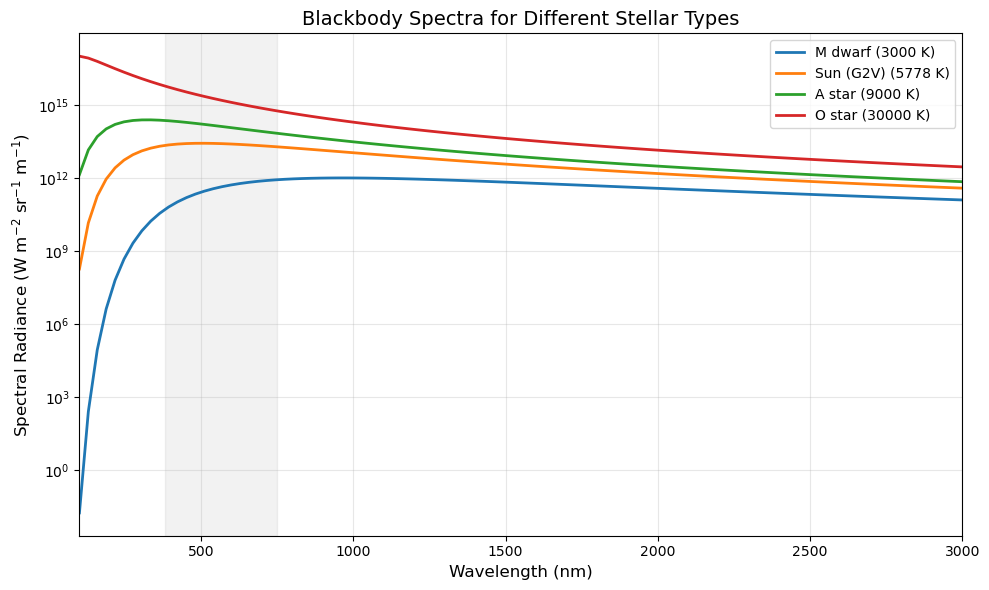

Notice how hotter stars peak at shorter wavelengths (Wien's displacement law)!


In [11]:
import matplotlib.pyplot as plt

# Compute spectra for different stellar types
temperatures = {
    'M dwarf': 3000,
    'Sun (G2V)': 5778,
    'A star': 9000,
    'O star': 30000
}

plt.figure(figsize=(10, 6))

for star_type, temp in temperatures.items():
    spectrum = planck_jax(wavelengths_jax, temp)
    plt.plot(wavelengths_nm, spectrum, label=f'{star_type} ({temp} K)', linewidth=2)

plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Spectral Radiance (W m$^{-2}$ sr$^{-1}$ m$^{-1}$)', fontsize=12)
plt.title('Blackbody Spectra for Different Stellar Types', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.xlim(50, 3000)

# Mark visible spectrum
plt.axvspan(380, 750, alpha=0.1, color='gray', label='Visible')

plt.tight_layout()
plt.show()

print("Notice how hotter stars peak at shorter wavelengths (Wien's displacement law)!")

## 1.5 Structured Control Flow

One of the most important differences between JAX and standard NumPy is how control flow (loops and conditionals) works.

When you use JAX's Just-In-Time (JIT) compilation (which we'll cover in the next notebook), your Python code is compiled into a static computation graph. Standard Python loops (`for`, `while`) and conditionals (`if/else`) are executed only **once** during the tracing phase.

If your control flow depends on **traced data** (values inside JAX arrays that change at runtime), you **must** use JAX's structured control flow primitives.

Here are the four main primitives:

1. `jax.lax.cond` (Conditional)
2. `jax.lax.while_loop` (While loop)
3. `jax.lax.fori_loop` (For loop)
4. `jax.lax.scan` (Loop with state carrying)

Let's look at simple examples of each.

In [ ]:
import jax

# --- 1. jax.lax.cond ---
# Equivalent to: if condition: true_fun(x) else: false_fun(x)

def apply_cond(x):
    return jax.lax.cond(
        x > 0,          # Condition
        lambda x: x,    # True branch
        lambda x: 0.0,  # False branch
        x               # Operand passed to branches
    )

print(f"cond( 5) = {apply_cond(5.0)}")
print(f"cond(-5) = {apply_cond(-5.0)}")


# --- 2. jax.lax.while_loop ---
# jax.lax.while_loop(cond_fun, body_fun, initial_val)
# is Equivalent to:
# val = init_val
# while cond_fun(val):
#     val = body_fun(val)
# return val

def find_first_power_of_two(n):
    """Find the first power of 2 greater than n."""
    initial_val = 1
    
    def cond_fun(val):
        return val <= n
        
    def body_fun(val):
        return val * 2
        
    return jax.lax.while_loop(cond_fun, body_fun, initial_val)

print(f"First power of 2 > 10: {find_first_power_of_two(10)}")
print(f"First power of 2 > 100: {find_first_power_of_two(100)}")


# --- 3. jax.lax.fori_loop ---
# jax.lax.fori_loop(lower, upper, body_fun, init_val)
# Equivalent to:
# val = init_val
# for i in range(lower, upper):
#     val = body_fun(i, val)
# return val

def sum_integers(n):
    """Sum numbers from 0 to n-1."""
    def body_fun(i, val):
        return val + i
    
    return jax.lax.fori_loop(0, n, body_fun, 0)

print(f"Sum of 0..9: {sum_integers(10)}")


# --- 4. jax.lax.scan ---
# jax.lax.scan(f, init, xs, length=None)
# is Equivalent to:
# carry = init
# ys = []
# iterable = xs if xs is not None else range(length)
# for x in iterable:
#     carry, y = f(carry, x)
#     ys.append(y)
# return carry, np.stack(ys)

def cumsum(arr):
    def step(carry, x):
        new_carry = carry + x
        return new_carry, new_carry  # (new_state, output)
    
    final_carry, result = jax.lax.scan(step, 0, arr)
    return result

data = jnp.array([1, 2, 3, 4, 5])
print(f"Original: {data}")
print(f"Cumulative sum (scan): {cumsum(data)}")

## Summary

Congratulations! You've completed the first notebook. Here's what you learned:

### Key Takeaways

1. **JAX's Value Proposition:**
   - NumPy-like API with automatic differentiation, JIT compilation, and GPU acceleration
   - Composable function transformations (`jit`, `grad`, `vmap`)
   - Ideal for scientific computing with gradients

2. **Critical Differences from NumPy:**
   - **Immutable arrays:** Use `.at[].set()` instead of in-place assignment
   - **float32 default:** Enable `jax_enable_x64` if you need float64 precision
   - **Functional programming:** JAX requires pure functions for transformations
   - **Structured Control Flow:** Use `jax.lax` primitives (`cond`, `scan`, etc.) instead of Python loops/ifs when tracing

3. **Practical Skills:**
   - Import and use `jax.numpy` as a drop-in replacement for NumPy
   - Check available devices with `jax.devices()`
   - Port NumPy code to JAX with minimal changes

### What's Next?

In the next notebook, we'll explore JAX's most powerful features:
- **JIT compilation** with `jax.jit` for dramatic speedups
- **Automatic differentiation** with `jax.grad` for computing exact gradients
- Practical applications to gradient-based optimization

The real magic of JAX begins when we start composing these transformations!

---

**Exercise for the curious:** Try modifying the blackbody function to compute the spectrum in frequency space instead of wavelength space. How would you take the derivative of the Planck function with respect to temperature? (We'll learn how to do this automatically in Notebook 2!)